In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
df = pd.read_csv("datasets/used_cars.csv")

In [105]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [106]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [108]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [109]:
df["clean_title"].value_counts(dropna=False)

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

In [110]:
df["clean_title"] = df["clean_title"].fillna("Unknown")
df["clean_title"].value_counts()

clean_title
Yes        3413
Unknown     596
Name: count, dtype: int64

In [111]:
df["price"]

0        $10,300
1        $38,005
2        $54,598
3        $15,500
4        $34,999
          ...   
4004    $349,950
4005     $53,900
4006     $90,998
4007     $62,999
4008     $40,000
Name: price, Length: 4009, dtype: str

In [112]:
price = df["price"].copy()

In [113]:
df["price"] = pd.to_numeric(df["price"].str.replace(",", "").str.replace("$", ""))

In [114]:
df["milage"] = pd.to_numeric(df["milage"].str.replace(",", "").str.replace("mi.", ""))

In [115]:
df["model"].nunique()

1898

In [116]:
df.model.value_counts()

model
M3 Base                       30
F-150 XLT                     24
Corvette Base                 22
1500 Laramie                  18
Model Y Long Range            17
                              ..
X3 xDrive28i                   1
CT 200h Base                   1
Martin DB7 Vantage Volante     1
Impala 2LZ                     1
Taycan                         1
Name: count, Length: 1898, dtype: int64

In [117]:
df[df["model"] == "Model Y Long Range"]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
518,Tesla,Model Y Long Range,2021,61308,NaN,425.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,42000
529,Tesla,Model Y Long Range,2021,69548,NaN,425.0HP Electric Motor Electric Fuel System,1-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,36300
703,Tesla,Model Y Long Range,2020,23100,NaN,425.0HP Electric Motor Electric Fuel System,A/T,Blue,White,None reported,Yes,36495
1071,Tesla,Model Y Long Range,2023,4786,NaN,425.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,48000
1212,Tesla,Model Y Long Range,2023,5844,NaN,425.0HP Electric Motor Electric Fuel System,A/T,White,Black,None reported,Yes,52000
1230,Tesla,Model Y Long Range,2021,14642,NaN,425.0HP Electric Motor Electric Fuel System,A/T,Red,Black,None reported,Yes,48500
1247,Tesla,Model Y Long Range,2022,12055,NaN,425.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,44400
1331,Tesla,Model Y Long Range,2023,10000,NaN,425.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,48000
1800,Tesla,Model Y Long Range,2022,4665,NaN,Dual Motor - Standard,Automatic,Silver,Black,None reported,Unknown,46598
2345,Tesla,Model Y Long Range,2022,21404,NaN,425.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,49500


In [118]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999


In [119]:
df.groupby("clean_title")["model_year"].median()

clean_title
Unknown    2020.5
Yes        2016.0
Name: model_year, dtype: float64

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          9.,  13.,  17.,  11.,  32.,  66.,  49., 132., 164., 113., 172.,
        265., 158., 409., 527., 315., 619., 704., 232.]),
 array([1974.        , 1975.66666667, 1977.33333333, 1979.        ,
        1980.66666667, 1982.33333333, 1984.        , 1985.66666667,
        1987.33333333, 1989.        , 1990.66666667, 1992.33333333,
        1994.        , 1995.66666667, 1997.33333333, 1999.        ,
        2000.66666667, 2002.33333333, 2004.        , 2005.66666667,
        2007.33333333, 2009.        , 2010.66666667, 2012.33333333,
        2014.        , 2015.66666667, 2017.33333333, 2019.        ,
        2020.66666667, 2022.33333333, 2024.        ]),
 <BarContainer object of 30 artists>)

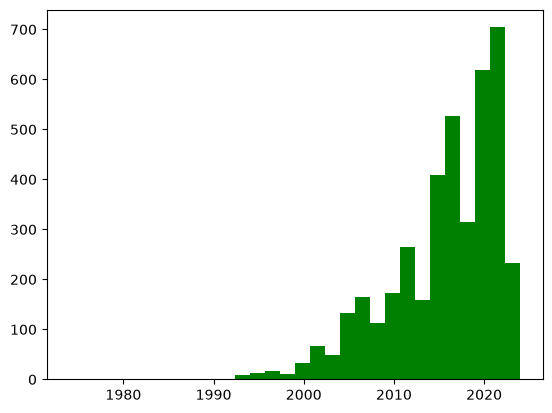

In [120]:
plt.hist(df["model_year"], bins=30, color="green")

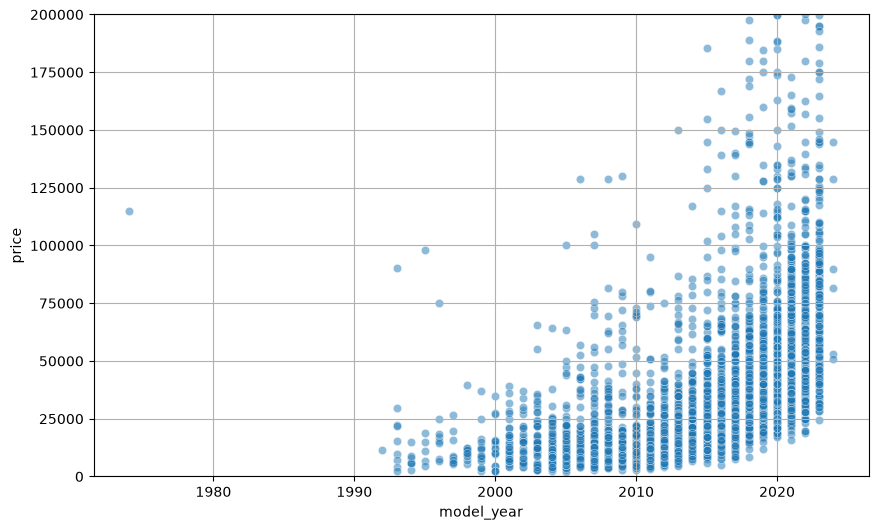

In [121]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="model_year", y="price", alpha=0.5)

plt.ylim(0, 200000)
plt.grid()
plt.show()

In [122]:
import re

engine = "300.0HP 3.7 L V6 Cylinder Engine Flex Fuel Capable"

match = re.search(r"(\d+(?:\.\d+))HP", engine)

v_ = re.search(r"(\d+(?:\.\d+)?)\s*(?:L|Litter|Liter)\b", engine)

In [123]:
df["engine_liters"] = df["engine"].str.extract(
    r"(\d+(?:\.\d+)?)\s*(?:L|Litter|Liter)\b"
).astype(float)

In [124]:
df["horsepower"] = df["engine"].str.extract(
    r"(\d+(?:\.\d+))HP"
).astype(float)

In [125]:
df["is_turbo"] = df["engine"].str.contains(
    "turbo", case=False, na=False
).astype(int)

In [126]:
df["cylinders"] = df["engine"].str.extract(
    r"\s*(?:V|v)(\d+)"
)

In [127]:
df["valves"] = df["engine"].str.extract(
    r"(\d+)V"
)

In [128]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_liters,horsepower,is_turbo,cylinders,valves
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,3.7,300.0,0,6,NaN
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,3.8,NaN,0,6,24
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598,3.5,NaN,0,NaN,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,3.5,354.0,0,6,NaN
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999,2.0,NaN,1,NaN,16


In [129]:
df.to_csv("datasets/cleaned_cars.csv", index=False)